# Power spectra from noisy KS and AKRA realizations

Set only `ANALYSIS_MODE`: use `"noiseless"` for index 0, or `"with_noise"` for the index-2 minus index-1 estimate. For every realization in the noisy mode, the signal estimate is computed as $C_\ell^{S+N}-N_\ell$. The curves show the realization median, and the shaded regions span the 16th--84th percentiles.

Noise subtraction removes only the additive shape-noise bias. KS does not explicitly invert the binary-mask mode coupling, so its reconstructed spectrum may retain a multiplicative response. This must be checked independently with the noiseless layer (index 0), using $T_\ell^{\rm KS}=\langle C_\ell^{\rm KS,noiseless}\rangle/\langle C_\ell^{\rm true}\rangle$. If the response is stable, the calibrated estimate is $(C_\ell^{S+N}-N_\ell)/T_\ell^{\rm KS}$. The spectra and ratios below are intentionally shown before applying this transfer-function correction.

In [1]:
import glob, os, warnings
import h5py
import healpy as hp
from matplotlib import pyplot as plt
import numpy as np

In [2]:
INPUT_DIR = "/home/yshi/Data/desy3_data2/desy3_sim_withNoise_N100_seed1044/"
OUTPUT_DIR = os.path.join(INPUT_DIR, "power_spectrum_analysis")
ELL_MAX_PLOT = 2000
files = sorted(glob.glob(os.path.join(INPUT_DIR, "realization*.hdf5")))[:100]
if not files: raise FileNotFoundError(f"No realization*.hdf5 files found in {INPUT_DIR}")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Found {len(files)} realizations")

Found 100 realizations


## Measure each realization

The same binary mask is applied to True, KS, and AKRA before their spherical-harmonic transforms.

In [3]:
ANALYSIS_MODE = "noiseless"  # Change only this value: "noiseless" or "with_noise".
if ANALYSIS_MODE not in ("noiseless", "with_noise"): raise ValueError("ANALYSIS_MODE must be 'noiseless' or 'with_noise'")
MAP_INDEX, NOISE_INDEX = (0, None) if ANALYSIS_MODE == "noiseless" else (2, 1)
OUTPUT_SUFFIX = "noiseless" if ANALYSIS_MODE == "noiseless" else "CminusN"
SPECTRUM_LABEL = "noiseless" if ANALYSIS_MODE == "noiseless" else r"$C_\ell-N_\ell$"
print(f"Analysis mode: {ANALYSIS_MODE}; map index={MAP_INDEX}; noise index={NOISE_INDEX}")

Analysis mode: noiseless; map index=0; noise index=None


In [4]:
def masked_alm(map_values, mask, lmax): return hp.map2alm(map_values * mask, lmax=lmax)

with h5py.File(files[0], "r") as f: nside, file_lmax = hp.npix2nside(f["mask"].size), int(f.attrs["lmax"])
lmax = min(file_lmax, 3 * nside - 1)
shape = (len(files), lmax + 1)
cl_true, cl_ks_noise, cl_ks_total, cl_akra_noise, cl_akra_total, cross_ks_noise, cross_ks_total, cross_akra_noise, cross_akra_total = (np.empty(shape) for _ in range(9))
for realization, filename in enumerate(files):
    with h5py.File(filename, "r") as f:
        mask = f["mask"][:].astype(float)
        alm_true, alm_ks_total, alm_akra_total = masked_alm(f["kappa_true"][:], mask, lmax), masked_alm(f["kappa_ks"][MAP_INDEX], mask, lmax), masked_alm(f["kappa_akra"][MAP_INDEX], mask, lmax)
        alm_ks_noise, alm_akra_noise = (np.zeros_like(alm_true), np.zeros_like(alm_true)) if NOISE_INDEX is None else (masked_alm(f["kappa_ks"][NOISE_INDEX], mask, lmax), masked_alm(f["kappa_akra"][NOISE_INDEX], mask, lmax))
        cl_true[realization], cl_ks_noise[realization], cl_ks_total[realization] = hp.alm2cl(alm_true), hp.alm2cl(alm_ks_noise), hp.alm2cl(alm_ks_total)
        cl_akra_noise[realization], cl_akra_total[realization] = hp.alm2cl(alm_akra_noise), hp.alm2cl(alm_akra_total)
        
        cross_ks_noise[realization], cross_ks_total[realization] = hp.alm2cl(alm_ks_noise, alm_true), hp.alm2cl(alm_ks_total, alm_true)
        cross_akra_noise[realization], cross_akra_total[realization] = hp.alm2cl(alm_akra_noise, alm_true), hp.alm2cl(alm_akra_total, alm_true)
    print(f"Finished {realization + 1}/{len(files)}: {os.path.basename(filename)}")

Finished 1/100: realization000.hdf5
Finished 2/100: realization001.hdf5
Finished 3/100: realization002.hdf5
Finished 4/100: realization003.hdf5
Finished 5/100: realization004.hdf5
Finished 6/100: realization005.hdf5
Finished 7/100: realization006.hdf5
Finished 8/100: realization007.hdf5
Finished 9/100: realization008.hdf5
Finished 10/100: realization009.hdf5
Finished 11/100: realization010.hdf5
Finished 12/100: realization011.hdf5
Finished 13/100: realization012.hdf5
Finished 14/100: realization013.hdf5
Finished 15/100: realization014.hdf5
Finished 16/100: realization015.hdf5
Finished 17/100: realization016.hdf5
Finished 18/100: realization017.hdf5
Finished 19/100: realization018.hdf5
Finished 20/100: realization019.hdf5
Finished 21/100: realization020.hdf5
Finished 22/100: realization021.hdf5
Finished 23/100: realization022.hdf5
Finished 24/100: realization023.hdf5
Finished 25/100: realization024.hdf5
Finished 26/100: realization025.hdf5
Finished 27/100: realization026.hdf5
Finished 2

## Subtract the reconstructed noise power

In [5]:
cl_ks, cl_akra = cl_ks_total - cl_ks_noise, cl_akra_total - cl_akra_noise
cross_ks, cross_akra = cross_ks_total, cross_akra_total
spectra = {"true": cl_true, "ks": cl_ks, "akra": cl_akra}
ell = np.arange(lmax + 1)
result_file = os.path.join(OUTPUT_DIR, f"power_spectra_masked_{OUTPUT_SUFFIX}.npz")
np.savez(result_file, ell=ell, files=np.asarray(files), cl_true=cl_true, cl_ks_noise=cl_ks_noise, cl_ks_total=cl_ks_total, cl_ks=cl_ks, cl_akra_noise=cl_akra_noise, cl_akra_total=cl_akra_total, cl_akra=cl_akra, cross_ks=cross_ks, cross_akra=cross_akra)
for name, values in spectra.items(): print(f"{name}: shape={values.shape}, mean finite={np.isfinite(values.mean(axis=0)).all()}")
print(f"Saved: {result_file}")

true: shape=(100, 2049), mean finite=True
ks: shape=(100, 2049), mean finite=True
akra: shape=(100, 2049), mean finite=True
Saved: /home/yshi/Data/desy3_data2/desy3_sim_withNoise_N100_seed1044/power_spectrum_analysis/power_spectra_masked_noiseless.npz


## Realization median and 16th--84th percentiles

Saved: /home/yshi/Data/desy3_data2/desy3_sim_withNoise_N100_seed1044/power_spectrum_analysis/power_spectra_masked_noiseless.pdf


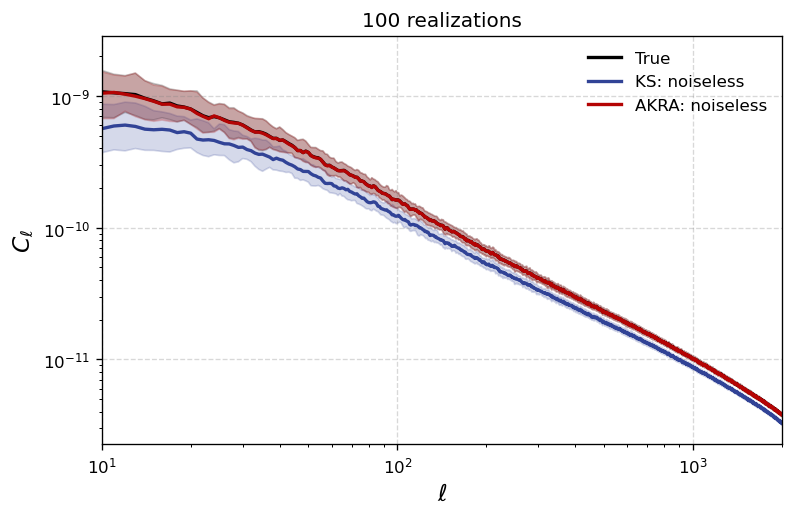

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4.2), dpi=120, layout="constrained")
for name, label, color in (("true", "True", "k"), ("ks", f"KS: {SPECTRUM_LABEL}", "#314396"), ("akra", f"AKRA: {SPECTRUM_LABEL}", "#B40404")):
    p16, median, p84 = np.nanpercentile(spectra[name], [16, 50, 84], axis=0)
    valid = (ell >= 2) & (ell <= ELL_MAX_PLOT) & (median > 0)
    band = valid & (p16 > 0)
    ax.loglog(ell[valid], median[valid], color=color, lw=2, label=label)
    ax.fill_between(ell, p16, p84, where=band, color=color, alpha=0.2)
ax.set_xlim(10, min(ELL_MAX_PLOT, lmax)); ax.set_xlabel(r"$\ell$", fontsize=14); ax.set_ylabel(r"$C_\ell$", fontsize=14)
ax.grid(ls="--", alpha=0.3, color="gray"); ax.legend(framealpha=0.0); ax.set_title(f"{len(files)} realizations")
figure_file = os.path.join(OUTPUT_DIR, f"power_spectra_masked_{OUTPUT_SUFFIX}.pdf")
fig.savefig(figure_file, transparent=True, dpi=300); fig.savefig(figure_file.replace(".pdf", ".png"), dpi=180)
print(f"Saved: {figure_file}")
plt.show()

## Auto- and cross-spectrum ratios

We define the auto-spectrum response as $R_\ell=C_\ell^{\rm rec}/C_\ell^{\rm true}$, where $C_\ell^{\rm rec}=C_\ell^{S+N}-N_\ell$, and the cross-spectrum response as $R_\ell^{\times}=C_\ell^{({\rm rec}\times{\rm true})}/C_\ell^{\rm true}$. The latter uses the direct $(S+N)\times\mathrm{true}$ cross spectrum because noise and signal are uncorrelated in the ensemble average. Curves show the realization median and bands span the 16th--84th percentiles.

In [7]:
def finite_percentiles(values):
    with warnings.catch_warnings(): warnings.simplefilter("ignore", RuntimeWarning); p16, median, p84 = np.nanpercentile(values, [16, 50, 84], axis=0)
    return median, p16, p84

ratio_ks_all = np.divide(cl_ks, cl_true, out=np.full_like(cl_ks, np.nan), where=cl_true > 0)
ratio_akra_all = np.divide(cl_akra, cl_true, out=np.full_like(cl_akra, np.nan), where=cl_true > 0)
cross_ratio_ks_all = np.divide(cross_ks, cl_true, out=np.full_like(cross_ks, np.nan), where=cl_true > 0)
cross_ratio_akra_all = np.divide(cross_akra, cl_true, out=np.full_like(cross_akra, np.nan), where=cl_true > 0)
ratio_ks_all_median, ratio_ks_all_p16, ratio_ks_all_p84 = finite_percentiles(ratio_ks_all)
ratio_akra_all_median, ratio_akra_all_p16, ratio_akra_all_p84 = finite_percentiles(ratio_akra_all)
cross_ratio_ks_all_median, cross_ratio_ks_all_p16, cross_ratio_ks_all_p84 = finite_percentiles(cross_ratio_ks_all)
cross_ratio_akra_all_median, cross_ratio_akra_all_p16, cross_ratio_akra_all_p84 = finite_percentiles(cross_ratio_akra_all)
ratio_file = os.path.join(OUTPUT_DIR, f"power_spectrum_auto_cross_ratio_{OUTPUT_SUFFIX}.npz")
np.savez(ratio_file, ell=ell, ratio_ks_all=ratio_ks_all, ratio_akra_all=ratio_akra_all, cross_ratio_ks_all=cross_ratio_ks_all, cross_ratio_akra_all=cross_ratio_akra_all, ratio_ks_all_median=ratio_ks_all_median, ratio_ks_all_p16=ratio_ks_all_p16, ratio_ks_all_p84=ratio_ks_all_p84, ratio_akra_all_median=ratio_akra_all_median, ratio_akra_all_p16=ratio_akra_all_p16, ratio_akra_all_p84=ratio_akra_all_p84, cross_ratio_ks_all_median=cross_ratio_ks_all_median, cross_ratio_ks_all_p16=cross_ratio_ks_all_p16, cross_ratio_ks_all_p84=cross_ratio_ks_all_p84, cross_ratio_akra_all_median=cross_ratio_akra_all_median, cross_ratio_akra_all_p16=cross_ratio_akra_all_p16, cross_ratio_akra_all_p84=cross_ratio_akra_all_p84)
print(f"Saved: {ratio_file}")

Saved: /home/yshi/Data/desy3_data2/desy3_sim_withNoise_N100_seed1044/power_spectrum_analysis/power_spectrum_auto_cross_ratio_noiseless.npz


In [8]:
## import my plot style
import sys
sys.path.insert(0, '/home/yshi/py_style')
import plt_style

Saved: /home/yshi/Data/desy3_data2/desy3_sim_withNoise_N100_seed1044/power_spectrum_analysis/power_spectrum_auto_cross_ratio_noiseless.pdf


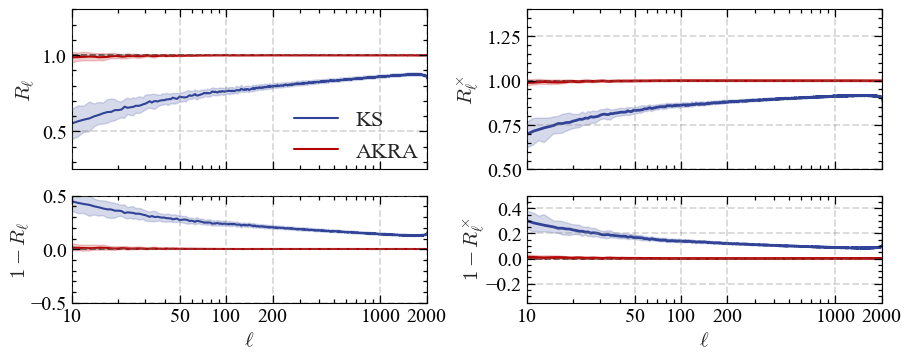

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(9, 3.5), dpi=100, layout="constrained", sharex=True, gridspec_kw={"height_ratios": [3, 2]})
xticks = [10, 50, 100, 200, 1000, 2000]
axs[0, 0].semilogx(ell, ratio_ks_all_median, label="KS", color="#314396"); 
axs[0, 0].fill_between(ell, ratio_ks_all_p16, ratio_ks_all_p84, alpha=0.2, color="#314396")
axs[0, 0].semilogx(ell, ratio_akra_all_median, label="AKRA", color="#B40404"); 
axs[0, 0].fill_between(ell, ratio_akra_all_p16, ratio_akra_all_p84, alpha=0.2, color="#B40404")
axs[0, 0].set_ylim(0.25, 1.3); 
axs[0, 0].set_ylabel(r"$R_\ell$", fontsize=15); 
axs[0, 0].legend(framealpha=0.0, fontsize=16, loc=(0.6, -0.01))
axs[1, 0].semilogx(ell, 1 - ratio_ks_all_median, color="#314396"); 
axs[1, 0].fill_between(ell, 1 - ratio_ks_all_p84, 1 - ratio_ks_all_p16, alpha=0.2, color="#314396")
axs[1, 0].semilogx(ell, 1 - ratio_akra_all_median, color="#B40404"); 
axs[1, 0].fill_between(ell, 1 - ratio_akra_all_p84, 1 - ratio_akra_all_p16, alpha=0.2, color="#B40404")
axs[0, 1].semilogx(ell, cross_ratio_ks_all_median, color="#314396", label="KS", lw=2); 
axs[0, 1].fill_between(ell, cross_ratio_ks_all_p16, cross_ratio_ks_all_p84, alpha=0.2, color="#314396")
axs[0, 1].semilogx(ell, cross_ratio_akra_all_median, color="#B40404", label="AKRA", lw=2); axs[0, 1].fill_between(ell, cross_ratio_akra_all_p16, cross_ratio_akra_all_p84, alpha=0.2, color="#B40404")
axs[0, 1].set_ylabel(r"$R_\ell^{\times}$", fontsize=15); 
axs[0, 1].set_ylim(0.5, 1.4)
axs[1, 1].semilogx(ell, 1 - cross_ratio_ks_all_median, color="#314396", lw=2); 
axs[1, 1].fill_between(ell, 1 - cross_ratio_ks_all_p84, 1 - cross_ratio_ks_all_p16, alpha=0.2, color="#314396")
axs[1, 1].semilogx(ell, 1 - cross_ratio_akra_all_median, color="#B40404", lw=2); 
axs[1, 1].fill_between(ell, 1 - cross_ratio_akra_all_p84, 1 - cross_ratio_akra_all_p16, alpha=0.2, color="#B40404")
for ax in axs.flat: ax.set_xlim(2, 2000); ax.set_xticks(xticks); ax.grid(ls="--", alpha=0.3, color="gray", lw=1.3)

axs[1, 0].set_xlabel(r"$\ell$", fontsize=15); axs[1, 0].set_ylabel(r"$1-R_\ell$", fontsize=15, labelpad=-1);
axs[1, 0].set_ylim(-0.5, 0.5); axs[1, 0].set_yticks([-0.5, 0.0, 0.5])

axs[1, 1].set_xlabel(r"$\ell$", fontsize=15); axs[1, 1].set_xticklabels(xticks); 
axs[1, 1].set_ylabel(r"$1-R_\ell^{\times}$", fontsize=15, labelpad=-1); 
axs[1, 1].set_ylim(-0.35, 0.5); axs[1, 1].set_yticks([-0.2, 0.0, 0.2, 0.4])
for ax, y in zip(axs.flat, [1, 1, 0, 0]): ax.axhline(y, color="k", ls="--", lw=1.2, alpha=0.7, zorder=0)
plt.xlim(10, 2000); 
ratio_figure = os.path.join(OUTPUT_DIR, f"power_spectrum_auto_cross_ratio_{OUTPUT_SUFFIX}.pdf")
fig.savefig(ratio_figure, transparent=True, dpi=300); 
# fig.savefig(ratio_figure.replace(".pdf", ".png"), dpi=180)
print(f"Saved: {ratio_figure}")
plt.show()